In [135]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [136]:
df = fetch_california_housing()

X = pd.DataFrame(df.data, columns=df.feature_names)
y = pd.Series(df.target, name="MedHouseVal")
housing = pd.concat([X, y], axis=1)

In [137]:
housing = housing.drop(columns= ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc'])

In [138]:
#rimozione outlier
for col in housing.columns:
    Q1 = housing[col].quantile(0.3)
    Q3 = housing[col].quantile(0.7)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    housing[col] = np.where(housing[col].between(lower, upper), housing[col], np.nan)

housing = housing.dropna()

In [139]:
def generate_comprehensive_features(df_input, cols_to_combine):
    df_eng = df_input.copy()
    math_cols = [c for c in cols_to_combine if c not in ['Latitude', 'Longitude', 'Geo_Cluster']]
    
    print(f"   -> Generazione combinazioni su {len(math_cols)} colonne base...")

    # A. LOGARITMI
    for col in math_cols:
        if df_eng[col].min() >= 0:
            df_eng[f'LOG_{col}'] = np.log1p(df_eng[col])

    # B. MOLTIPLICAZIONI
    for col1, col2 in itertools.combinations(math_cols, 2):
        col_name = f'MULT_{col1}_x_{col2}'
        df_eng[col_name] = df_eng[col1] * df_eng[col2]

    # C. DIVISIONI / RAPPORTI
    for col1, col2 in itertools.permutations(math_cols, 2):
        col_name = f'RATIO_{col1}_div_{col2}'
        df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)

    return df_eng

In [140]:
cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full= generate_comprehensive_features(X, cols_for_math)

# Pulizia inf/nan generati dalle divisioni
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)

housing = pd.concat([X_full, y], axis=1)
housing.info()

   -> Generazione combinazioni su 6 colonne base...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 60 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   MedInc                          20640 non-null  float64
 1   HouseAge                        20640 non-null  float64
 2   AveRooms                        20640 non-null  float64
 3   AveBedrms                       20640 non-null  float64
 4   Population                      20640 non-null  float64
 5   AveOccup                        20640 non-null  float64
 6   Latitude                        20640 non-null  float64
 7   Longitude                       20640 non-null  float64
 8   LOG_MedInc                      20640 non-null  float64
 9   LOG_HouseAge                    20640 non-null  float64
 10  LOG_AveRooms                    20640 non-null  float64
 11  LOG_AveBedrms                   20640 non

In [141]:
# --- 1. PREPARAZIONE DATI ---
# Carichiamo il dataset
X = housing.drop('MedHouseVal', axis=1)
y = housing['MedHouseVal']

# Split Train/Test (Fondamentale per valutare l'overfitting)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

# !!! PASSAGGIO CRUCIALE !!!
# A differenza dei Decision Tree, le Reti Neurali richiedono input scalati.
# Se non lo fate, i gradienti esploderanno o il training sarà lentissimo.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

print(f"Shape Input: {X_train.shape[1]} features") # Dovrebbe essere 8

# --- 2. COSTRUZIONE MODELLO (Architecture Design) ---
model_reg = models.Sequential([
    # Input Layer implicito nella definizione del primo Dense
    # Struttura a "Imbuto": Partiamo larghi e stringiamo
    layers.Dense(128, activation="relu", input_shape=X_train.shape[1:]),
    
    # Secondo strato hidden per catturare non-linearità complesse
    layers.Dense(128, activation="relu"),
    
    layers.Dense(64, activation="relu"),
    
    # OUTPUT LAYER (Regressione)
    # 1 solo neurone (prezzo). 
    # Nessuna attivazione (può essere qualsiasi valore positivo).
    layers.Dense(1) 
])

# --- 3. COMPILAZIONE (Il cervello) ---
model_reg.compile(
    loss="mse",                # Mean Squared Error: standard per regressione
    optimizer="adam",          # Adam gestisce il learning rate da solo
    metrics=["mae"]            # Monitoriamo l'errore assoluto (più leggibile dell'MSE)
)

# --- 4. TRAINING (Il sudore) ---
history = model_reg.fit(
    X_train, y_train,
    epochs=50,                 # Proviamo 20 giri completi
    batch_size=32,             # Aggiorniamo i pesi ogni 32 case
    validation_data=(X_valid, y_valid), # Controllo in tempo reale
    verbose=1
)

# --- 5. ANALISI DEI RISULTATI ---
# Valutazione finale sul Test Set (dati mai visti)
mse_test, mae_test = model_reg.evaluate(X_test, y_test)
print(f"\nErrore Medio Assoluto sul Test Set: {mae_test:.2f} (in centinaia di migliaia di $)")

Shape Input: 59 features
Epoch 1/50
363/363 [==============================] - 1s 1ms/step - loss: 0.6575 - mae: 0.5299 - val_loss: 0.6596 - val_mae: 0.4630
Epoch 2/50
363/363 [==============================] - 0s 871us/step - loss: 0.4150 - mae: 0.4430 - val_loss: 16.2782 - val_mae: 0.5297
Epoch 3/50
363/363 [==============================] - 0s 879us/step - loss: 0.4782 - mae: 0.4331 - val_loss: 0.5244 - val_mae: 0.4158
Epoch 4/50
363/363 [==============================] - 0s 861us/step - loss: 0.3508 - mae: 0.4140 - val_loss: 0.5179 - val_mae: 0.4007
Epoch 5/50
363/363 [==============================] - 0s 871us/step - loss: 0.3524 - mae: 0.4081 - val_loss: 4.6416 - val_mae: 0.4717
Epoch 6/50
363/363 [==============================] - 0s 857us/step - loss: 0.3636 - mae: 0.4094 - val_loss: 0.3920 - val_mae: 0.4023
Epoch 7/50
363/363 [==============================] - 0s 851us/step - loss: 0.3190 - mae: 0.3959 - val_loss: 9.6982 - val_mae: 0.4593
Epoch 8/50
363/363 [==================

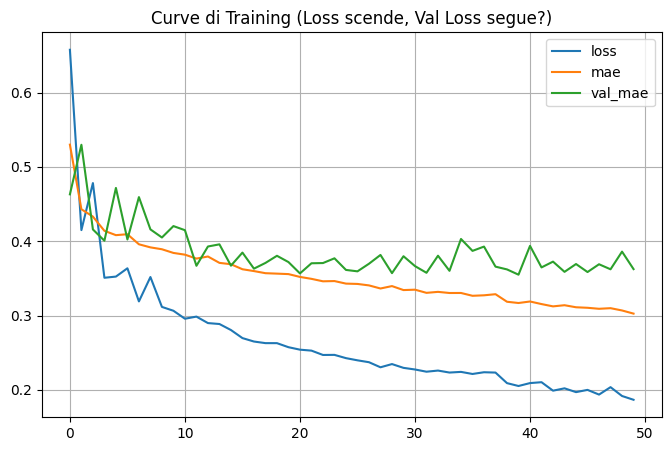

In [143]:
# Visualizzazione della curva di apprendimento
df_graph = pd.DataFrame(history.history)
df_graph = df_graph.drop(columns=["val_loss"], errors="ignore")
df_graph.plot(figsize=(8, 5))
plt.grid(True)
plt.title("Curve di Training (Loss scende, Val Loss segue?)")
plt.show()

- Versione base: Errore Medio Assoluto sul Test Set: 0.39
- Rimozione outliers 0.7, drop ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']: Errore Medio Assoluto sul Test Set: 0.49
- Rimozione outliers 0.7, drop ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc'], con features combinate, neuroni 32, 16: Errore Medio Assoluto sul Test Set: 0.40 
- Rimozione outliers 0.7, drop ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc'], con features combinate, neuroni 128, 128, 64: Errore Medio Assoluto sul Test Set: 0.37
- Rimozione outliers 0.7, drop ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc'], con features combinate, neuroni 128, 64: Errore Medio Assoluto sul Test Set: 0.39
- Rimozione outliers 0.7, drop ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc'], con features combinate, neuroni 128, 128, 64, batch size 64: Errore Medio Assoluto sul Test Set: 0.38
- Rimozione outliers 0.7, drop ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc'], con features combinate, neuroni 128, 128, 64, epoche 50: Errore Medio Assoluto sul Test Set: 0.37 (un pò di overfitting con mae che migliora e val mae che rimane un pò stabile)